In [24]:
# ============================================================
# INSTALLS (KAGGLE NOTEBOOK)
# ============================================================

!pip install transformers -q

In [25]:
# ============================================================
# IMPORTS
# ============================================================

import torch
import torch.nn as nn

from transformers import (
    AutoTokenizer,
    AutoModel
)

In [26]:
# ============================================================
# DEVICE CONFIG
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cuda


In [27]:
# ============================================================
# FINAL LIGHTWEIGHT TEXT PIPELINE
# ============================================================

class TextEmotionEncoder(nn.Module):

    def __init__(
        self,
        model_name="roberta-base",
        projection_dim=128,
        dropout=0.3
    ):

        super(TextEmotionEncoder, self).__init__()

        # ----------------------------------------------------
        # RoBERTa Backbone
        # ----------------------------------------------------
        self.text_encoder = AutoModel.from_pretrained(model_name)

        hidden_size = self.text_encoder.config.hidden_size  # 768

        # ----------------------------------------------------
        # Projection Head
        # 768 → 256 → 128
        # ----------------------------------------------------
        self.projection_head = nn.Sequential(

            nn.Linear(hidden_size, 256),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(256, projection_dim)

        )

        # ----------------------------------------------------
        # Layer Normalization
        # ----------------------------------------------------
        self.layer_norm = nn.LayerNorm(projection_dim)

        # ----------------------------------------------------
        # Final Dropout
        # ----------------------------------------------------
        self.dropout = nn.Dropout(dropout)

        # ----------------------------------------------------
        # Confidence Gate
        #
        # Learns:
        # "How much should text matter?"
        # ----------------------------------------------------
        self.gate_network = nn.Sequential(

            nn.Linear(projection_dim, projection_dim),

            nn.Sigmoid()

        )

    def forward(self, input_ids, attention_mask):

        # ----------------------------------------------------
        # RoBERTa Forward Pass
        # ----------------------------------------------------
        outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # ----------------------------------------------------
        # CLS Token Embedding
        #
        # Shape:
        # (B, 768)
        # ----------------------------------------------------
        cls_embedding = outputs.last_hidden_state[:, 0, :]

        # ----------------------------------------------------
        # Projection Head
        # ----------------------------------------------------
        text_embedding = self.projection_head(cls_embedding)

        # ----------------------------------------------------
        # LayerNorm
        # ----------------------------------------------------
        text_embedding = self.layer_norm(text_embedding)

        # ----------------------------------------------------
        # Dropout
        # ----------------------------------------------------
        text_embedding = self.dropout(text_embedding)

        # ----------------------------------------------------
        # Confidence Gate
        # ----------------------------------------------------
        gate = self.gate_network(text_embedding)

        # ----------------------------------------------------
        # Final Gated Text Representation
        # ----------------------------------------------------
        gated_text_embedding = gate * text_embedding

        return {

            "cls_embedding": cls_embedding,

            "text_embedding": text_embedding,

            "gated_text_embedding": gated_text_embedding,

            "gate_values": gate
        }

In [28]:
# ============================================================
# TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

In [29]:
# ============================================================
# MODEL INITIALIZATION
# ============================================================

text_model = TextEmotionEncoder().to(device)

print(text_model)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TextEmotionEncoder(
  (text_encoder): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNo

In [30]:
# ============================================================
# FINAL FUSION-READY OUTPUT
# ============================================================

text_embedding = outputs["gated_text_embedding"]

print(text_embedding.shape)

torch.Size([3, 128])


In [31]:
# ============================================================
# ADAPTIVE GATED FUSION MODULE
# ============================================================

class AdaptiveFusion(nn.Module):

    def __init__(
        self,
        speech_dim=512,
        text_dim=128,
        fusion_dim=256,
        num_classes=7,
        dropout=0.3
    ):

        super(AdaptiveFusion, self).__init__()

        # ----------------------------------------------------
        # SPEECH PROJECTION
        # 512 → 256
        # ----------------------------------------------------
        self.speech_projection = nn.Sequential(

            nn.Linear(speech_dim, fusion_dim),

            nn.LayerNorm(fusion_dim),

            nn.GELU(),

            nn.Dropout(dropout)

        )

        # ----------------------------------------------------
        # TEXT PROJECTION
        # 128 → 256
        # ----------------------------------------------------
        self.text_projection = nn.Sequential(

            nn.Linear(text_dim, fusion_dim),

            nn.LayerNorm(fusion_dim),

            nn.GELU(),

            nn.Dropout(dropout)

        )

        # ----------------------------------------------------
        # ADAPTIVE GATE
        #
        # Learns:
        # "How much should speech dominate?"
        # ----------------------------------------------------
        self.fusion_gate = nn.Sequential(

            nn.Linear(fusion_dim * 2, fusion_dim),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(fusion_dim, fusion_dim),

            nn.Sigmoid()

        )

        # ----------------------------------------------------
        # FINAL CLASSIFIER
        # ----------------------------------------------------
        self.classifier = nn.Sequential(

            nn.Linear(fusion_dim, 128),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(128, num_classes)

        )

    def forward(
        self,
        speech_embedding,
        text_embedding
    ):

        # ----------------------------------------------------
        # PROJECT BOTH MODALITIES
        # ----------------------------------------------------
        speech_proj = self.speech_projection(
            speech_embedding
        )

        text_proj = self.text_projection(
            text_embedding
        )

        # ----------------------------------------------------
        # CONCAT FOR GATE COMPUTATION
        # ----------------------------------------------------
        combined = torch.cat(
            [speech_proj, text_proj],
            dim=-1
        )

        # ----------------------------------------------------
        # GATE VALUES
        # Shape:
        # (B, fusion_dim)
        # ----------------------------------------------------
        alpha = self.fusion_gate(combined)

        # ----------------------------------------------------
        # ADAPTIVE FUSION
        #
        # Speech weighted by alpha
        # Text weighted by (1-alpha)
        # ----------------------------------------------------
        fused_embedding = (

            alpha * speech_proj

            +

            (1 - alpha) * text_proj

        )

        # ----------------------------------------------------
        # CLASSIFICATION
        # ----------------------------------------------------
        logits = self.classifier(fused_embedding)

        return {

            "speech_proj": speech_proj,

            "text_proj": text_proj,

            "fusion_gate": alpha,

            "fused_embedding": fused_embedding,

            "logits": logits
        }

In [37]:
# ============================================================
# MODEL INITIALIZATION
# ============================================================

fusion_model = AdaptiveFusion(

    speech_dim=128,   # IMPORTANT CHANGE

    text_dim=768,

    fusion_dim=256,

    num_classes=7

).to(device)

print(fusion_model)

AdaptiveFusion(
  (speech_projection): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
  )
  (text_projection): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
  )
  (fusion_gate): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): Sigmoid()
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=7, bias=True)
  )
)


In [33]:
# ============================================================
# LOAD PRECOMPUTED SPEECH EMBEDDINGS
# ============================================================

import os
import torch

# Example path
EMBEDDING_PATH = "/kaggle/input/datasets/kushalman/speech-embeddings"

print(os.listdir(EMBEDDING_PATH))

# ============================================================
# LOAD SPEECH EMBEDDINGS
# ============================================================

import numpy as np

speech_embeddings = np.load(

    f"{EMBEDDING_PATH}/full_speech_embeddings.npy"

)

speech_embeddings = torch.tensor(
    speech_embeddings,
    dtype=torch.float32
).to(device)

print("Speech Embedding Shape:")
print(speech_embeddings.shape)

# ============================================================
# TEXT PIPELINE
# ============================================================

text_outputs = text_model(

    input_ids=input_ids,

    attention_mask=attention_mask

)

text_embeddings = text_outputs[
    "gated_text_embedding"
]

print("Text Embedding Shape:")
print(text_embeddings.shape)

# ============================================================
# FUSION PIPELINE
# ============================================================

fusion_outputs = fusion_model(

    speech_embedding=speech_embeddings[:3],

    text_embedding=text_embeddings

)

print("\nFusion Logits Shape:")
print(fusion_outputs["logits"].shape)

['full_speech_labels.npy', 'full_speech_embeddings.npy']
Speech Embedding Shape:
torch.Size([2800, 128])
Text Embedding Shape:
torch.Size([3, 128])

Fusion Logits Shape:
torch.Size([3, 7])


# FUSION PIPELINE

In [34]:
# ============================================================
# LOAD SPEECH EMBEDDINGS + LABELS
# ============================================================

import numpy as np
import torch

EMBEDDING_PATH = "/kaggle/input/datasets/kushalman/speech-embeddings"

speech_embeddings = np.load(
    f"{EMBEDDING_PATH}/full_speech_embeddings.npy"
)

speech_labels = np.load(
    f"{EMBEDDING_PATH}/full_speech_labels.npy"
)

speech_embeddings = torch.tensor(
    speech_embeddings,
    dtype=torch.float32
)

speech_labels = torch.tensor(
    speech_labels,
    dtype=torch.long
)

print("Speech Embeddings Shape:")
print(speech_embeddings.shape)

print("\nLabels Shape:")
print(speech_labels.shape)

Speech Embeddings Shape:
torch.Size([2800, 128])

Labels Shape:
torch.Size([2800])


In [36]:
# ============================================================
# LOAD TEXT EMBEDDINGS
# ============================================================

text_embeddings = np.load(
    "/kaggle/input/datasets/kushalman/text-embeddings/full_text_embeddings.npy"
)

text_embeddings = torch.tensor(
    text_embeddings,
    dtype=torch.float32
)

print("Text Embeddings Shape:")
print(text_embeddings.shape)

Text Embeddings Shape:
torch.Size([2800, 768])


In [38]:
# ============================================================
# LOAD LABELS
# ============================================================

labels = np.load(
    "/kaggle/input/datasets/kushalman/speech-embeddings/full_speech_labels.npy"
)

labels = torch.tensor(
    labels,
    dtype=torch.long
)

print("Labels Shape:")
print(labels.shape)

Labels Shape:
torch.Size([2800])


In [39]:
# ============================================================
# VERIFY ALIGNMENT
# ============================================================

print("Speech:", speech_embeddings.shape)

print("Text:", text_embeddings.shape)

print("Labels:", labels.shape)

Speech: torch.Size([2800, 128])
Text: torch.Size([2800, 768])
Labels: torch.Size([2800])


In [40]:
# ============================================================
# FUSION DATASET
# ============================================================

from torch.utils.data import Dataset


class FusionDataset(Dataset):

    def __init__(
        self,
        speech_embeddings,
        text_embeddings,
        labels
    ):

        self.speech_embeddings = speech_embeddings

        self.text_embeddings = text_embeddings

        self.labels = labels

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        return {

            "speech_embedding":
                self.speech_embeddings[idx],

            "text_embedding":
                self.text_embeddings[idx],

            "label":
                self.labels[idx]
        }

In [41]:
# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

indices = np.arange(len(labels))

train_idx, val_idx = train_test_split(

    indices,

    test_size=0.2,

    stratify=labels,

    random_state=42
)

In [42]:
# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = FusionDataset(

    speech_embeddings[train_idx],

    text_embeddings[train_idx],

    labels[train_idx]
)

val_dataset = FusionDataset(

    speech_embeddings[val_idx],

    text_embeddings[val_idx],

    labels[val_idx]
)

In [43]:
# ============================================================
# DATALOADERS
# ============================================================

from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False
)

print("Train Batches:", len(train_loader))

print("Val Batches:", len(val_loader))

Train Batches: 70
Val Batches: 18


In [45]:
# ============================================================
# FUSION MODEL INITIALIZATION
# ============================================================

fusion_model = AdaptiveFusion(

    speech_dim=128,

    text_dim=768,

    fusion_dim=256,

    num_classes=7

).to(device)

print(fusion_model)

AdaptiveFusion(
  (speech_projection): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
  )
  (text_projection): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
  )
  (fusion_gate): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): Sigmoid()
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=7, bias=True)
  )
)


In [46]:
# ============================================================
# LOSS + OPTIMIZER
# ============================================================

import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(

    fusion_model.parameters(),

    lr=1e-4,

    weight_decay=1e-4
)

In [47]:
# ============================================================
# SINGLE BATCH TEST
# ============================================================

batch = next(iter(train_loader))

speech_batch = batch[
    "speech_embedding"
].to(device)

text_batch = batch[
    "text_embedding"
].to(device)

labels_batch = batch[
    "label"
].to(device)

fusion_outputs = fusion_model(

    speech_embedding=speech_batch,

    text_embedding=text_batch
)

logits = fusion_outputs["logits"]

print("Speech Shape:")
print(speech_batch.shape)

print("\nText Shape:")
print(text_batch.shape)

print("\nLogits Shape:")
print(logits.shape)

Speech Shape:
torch.Size([32, 128])

Text Shape:
torch.Size([32, 768])

Logits Shape:
torch.Size([32, 7])


In [48]:
# ============================================================
# TRAINING LOOP
# ============================================================

from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

EPOCHS = 20

best_val_f1 = 0.0


for epoch in range(EPOCHS):

    # ========================================================
    # TRAINING
    # ========================================================

    fusion_model.train()

    train_losses = []

    train_preds = []

    train_labels = []

    train_bar = tqdm(train_loader)

    for batch in train_bar:

        # ----------------------------------------------------
        # LOAD BATCH
        # ----------------------------------------------------

        speech_batch = batch[
            "speech_embedding"
        ].to(device)

        text_batch = batch[
            "text_embedding"
        ].to(device)

        labels_batch = batch[
            "label"
        ].to(device)

        # ----------------------------------------------------
        # ZERO GRAD
        # ----------------------------------------------------

        optimizer.zero_grad()

        # ----------------------------------------------------
        # FORWARD PASS
        # ----------------------------------------------------

        fusion_outputs = fusion_model(

            speech_embedding=speech_batch,

            text_embedding=text_batch
        )

        logits = fusion_outputs["logits"]

        # ----------------------------------------------------
        # LOSS
        # ----------------------------------------------------

        loss = criterion(

            logits,

            labels_batch
        )

        # ----------------------------------------------------
        # BACKPROP
        # ----------------------------------------------------

        loss.backward()

        optimizer.step()

        # ----------------------------------------------------
        # TRACKING
        # ----------------------------------------------------

        train_losses.append(loss.item())

        preds = torch.argmax(
            logits,
            dim=1
        )

        train_preds.extend(
            preds.cpu().numpy()
        )

        train_labels.extend(
            labels_batch.cpu().numpy()
        )

        train_bar.set_description(

            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Loss: {loss.item():.4f}"
        )

    # ========================================================
    # TRAIN METRICS
    # ========================================================

    train_acc = accuracy_score(

        train_labels,

        train_preds
    )

    train_f1 = f1_score(

        train_labels,

        train_preds,

        average="macro"
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    fusion_model.eval()

    val_losses = []

    val_preds = []

    val_labels = []

    with torch.no_grad():

        for batch in val_loader:

            speech_batch = batch[
                "speech_embedding"
            ].to(device)

            text_batch = batch[
                "text_embedding"
            ].to(device)

            labels_batch = batch[
                "label"
            ].to(device)

            fusion_outputs = fusion_model(

                speech_embedding=speech_batch,

                text_embedding=text_batch
            )

            logits = fusion_outputs["logits"]

            loss = criterion(

                logits,

                labels_batch
            )

            val_losses.append(loss.item())

            preds = torch.argmax(
                logits,
                dim=1
            )

            val_preds.extend(
                preds.cpu().numpy()
            )

            val_labels.extend(
                labels_batch.cpu().numpy()
            )

    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_acc = accuracy_score(

        val_labels,

        val_preds
    )

    val_f1 = f1_score(

        val_labels,

        val_preds,

        average="macro"
    )

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        torch.save(

            fusion_model.state_dict(),

            "best_fusion_model.pt"
        )

    # ========================================================
    # EPOCH SUMMARY
    # ========================================================

    print("\n" + "="*50)

    print(f"EPOCH {epoch+1}/{EPOCHS}")

    print("="*50)

    print(f"Train Loss : {sum(train_losses)/len(train_losses):.4f}")

    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Train F1   : {train_f1:.4f}")

    print("\n")

    print(f"Val Loss   : {sum(val_losses)/len(val_losses):.4f}")

    print(f"Val Acc    : {val_acc:.4f}")

    print(f"Val F1     : {val_f1:.4f}")

    print("\nBest Val F1:", best_val_f1)

Epoch 1/20 | Loss: 1.2098: 100%|██████████| 70/70 [00:00<00:00, 82.35it/s] 



EPOCH 1/20
Train Loss : 1.6834
Train Acc  : 0.6116
Train F1   : 0.6246


Val Loss   : 1.1550
Val Acc    : 0.9768
Val F1     : 0.9767

Best Val F1: 0.9766688217817885


Epoch 2/20 | Loss: 0.2428: 100%|██████████| 70/70 [00:00<00:00, 213.49it/s]



EPOCH 2/20
Train Loss : 0.4984
Train Acc  : 0.9812
Train F1   : 0.9812


Val Loss   : 0.1056
Val Acc    : 0.9821
Val F1     : 0.9820

Best Val F1: 0.9820430121318399


Epoch 3/20 | Loss: 0.0466: 100%|██████████| 70/70 [00:00<00:00, 213.06it/s]


...


EPOCH 18/20
Train Loss : 0.0134
Train Acc  : 0.9960
Train F1   : 0.9960


Val Loss   : 0.0166
Val Acc    : 0.9929
Val F1     : 0.9929

Best Val F1: 0.9946427873856679


Epoch 19/20 | Loss: 0.0109: 100%|██████████| 70/70 [00:00<00:00, 216.48it/s]



EPOCH 19/20
Train Loss : 0.0145
Train Acc  : 0.9964
Train F1   : 0.9964


Val Loss   : 0.0167
Val Acc    : 0.9911
Val F1     : 0.9911

Best Val F1: 0.9946427873856679


Epoch 20/20 | Loss: 0.0038: 100%|██████████| 70/70 [00:00<00:00, 212.72it/s]



EPOCH 20/20
Train Loss : 0.0139
Train Acc  : 0.9955
Train F1   : 0.9955


Val Loss   : 0.0165
Val Acc    : 0.9929
Val F1     : 0.9929

Best Val F1: 0.9946427873856679


In [49]:
print(speech_embeddings[0][:10])

tensor([ 0.2000, -0.0700,  0.0487,  0.1007,  0.0317,  0.0461, -0.1107, -0.0073,
        -0.0810, -0.1259])


In [50]:
# ============================================================
# SPEECH-ONLY DATASET
# ============================================================

from torch.utils.data import Dataset


class SpeechOnlyDataset(Dataset):

    def __init__(
        self,
        speech_embeddings,
        labels
    ):

        self.speech_embeddings = speech_embeddings

        self.labels = labels

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        return {

            "speech_embedding":
                self.speech_embeddings[idx],

            "label":
                self.labels[idx]
        }

In [51]:
# ============================================================
# CREATE SPEECH DATASETS
# ============================================================

train_dataset_speech = SpeechOnlyDataset(

    speech_embeddings[train_idx],

    labels[train_idx]
)

val_dataset_speech = SpeechOnlyDataset(

    speech_embeddings[val_idx],

    labels[val_idx]
)

In [52]:
# ============================================================
# SPEECH DATALOADERS
# ============================================================

from torch.utils.data import DataLoader

train_loader_speech = DataLoader(

    train_dataset_speech,

    batch_size=32,

    shuffle=True
)

val_loader_speech = DataLoader(

    val_dataset_speech,

    batch_size=32,

    shuffle=False
)

print("Train Batches:", len(train_loader_speech))

print("Val Batches:", len(val_loader_speech))

Train Batches: 70
Val Batches: 18


In [53]:
# ============================================================
# SPEECH-ONLY CLASSIFIER
# ============================================================

import torch.nn as nn


class SpeechOnlyClassifier(nn.Module):

    def __init__(
        self,
        input_dim=128,
        hidden_dim=256,
        num_classes=7,
        dropout=0.3
    ):

        super(SpeechOnlyClassifier, self).__init__()

        self.model = nn.Sequential(

            nn.Linear(input_dim, hidden_dim),

            nn.LayerNorm(hidden_dim),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(hidden_dim, 128),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(128, num_classes)

        )

    def forward(self, speech_embedding):

        logits = self.model(
            speech_embedding
        )

        return logits

In [54]:
# ============================================================
# INITIALIZE SPEECH MODEL
# ============================================================

speech_model = SpeechOnlyClassifier(

    input_dim=128,

    hidden_dim=256,

    num_classes=7

).to(device)

print(speech_model)

SpeechOnlyClassifier(
  (model): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): GELU(approximate='none')
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=128, out_features=7, bias=True)
  )
)


In [55]:
# ============================================================
# LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(

    speech_model.parameters(),

    lr=1e-4,

    weight_decay=1e-4
)

In [56]:
# ============================================================
# SPEECH-ONLY TRAINING LOOP
# ============================================================

from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

EPOCHS = 20

best_val_f1 = 0.0


for epoch in range(EPOCHS):

    # ========================================================
    # TRAINING
    # ========================================================

    speech_model.train()

    train_losses = []

    train_preds = []

    train_labels = []

    train_bar = tqdm(train_loader_speech)

    for batch in train_bar:

        speech_batch = batch[
            "speech_embedding"
        ].to(device)

        labels_batch = batch[
            "label"
        ].to(device)

        optimizer.zero_grad()

        logits = speech_model(
            speech_batch
        )

        loss = criterion(
            logits,
            labels_batch
        )

        loss.backward()

        optimizer.step()

        train_losses.append(loss.item())

        preds = torch.argmax(
            logits,
            dim=1
        )

        train_preds.extend(
            preds.cpu().numpy()
        )

        train_labels.extend(
            labels_batch.cpu().numpy()
        )

        train_bar.set_description(

            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Loss: {loss.item():.4f}"
        )

    # ========================================================
    # TRAIN METRICS
    # ========================================================

    train_acc = accuracy_score(

        train_labels,

        train_preds
    )

    train_f1 = f1_score(

        train_labels,

        train_preds,

        average="macro"
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    speech_model.eval()

    val_losses = []

    val_preds = []

    val_labels = []

    with torch.no_grad():

        for batch in val_loader_speech:

            speech_batch = batch[
                "speech_embedding"
            ].to(device)

            labels_batch = batch[
                "label"
            ].to(device)

            logits = speech_model(
                speech_batch
            )

            loss = criterion(
                logits,
                labels_batch
            )

            val_losses.append(loss.item())

            preds = torch.argmax(
                logits,
                dim=1
            )

            val_preds.extend(
                preds.cpu().numpy()
            )

            val_labels.extend(
                labels_batch.cpu().numpy()
            )

    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_acc = accuracy_score(

        val_labels,

        val_preds
    )

    val_f1 = f1_score(

        val_labels,

        val_preds,

        average="macro"
    )

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        torch.save(

            speech_model.state_dict(),

            "best_speech_model.pt"
        )

    # ========================================================
    # EPOCH SUMMARY
    # ========================================================

    print("\n" + "="*50)

    print(f"EPOCH {epoch+1}/{EPOCHS}")

    print("="*50)

    print(f"Train Loss : {sum(train_losses)/len(train_losses):.4f}")

    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Train F1   : {train_f1:.4f}")

    print("\n")

    print(f"Val Loss   : {sum(val_losses)/len(val_losses):.4f}")

    print(f"Val Acc    : {val_acc:.4f}")

    print(f"Val F1     : {val_f1:.4f}")

    print("\nBest Val F1:", best_val_f1)

Epoch 1/20 | Loss: 1.0563: 100%|██████████| 70/70 [00:00<00:00, 293.62it/s]



EPOCH 1/20
Train Loss : 1.5575
Train Acc  : 0.6705
Train F1   : 0.6804


Val Loss   : 0.9944
Val Acc    : 0.9786
Val F1     : 0.9785

Best Val F1: 0.9784849838552229


Epoch 2/20 | Loss: 0.2132: 100%|██████████| 70/70 [00:00<00:00, 297.67it/s]



EPOCH 2/20
Train Loss : 0.5283
Train Acc  : 0.9808
Train F1   : 0.9807


Val Loss   : 0.1724
Val Acc    : 0.9857
Val F1     : 0.9856

Best Val F1: 0.9856397371808326


Epoch 3/20 | Loss: 0.0716: 100%|██████████| 70/70 [00:00<00:00, 291.05it/s]


...


EPOCH 18/20
Train Loss : 0.0137
Train Acc  : 0.9978
Train F1   : 0.9978


Val Loss   : 0.0188
Val Acc    : 0.9929
Val F1     : 0.9929

Best Val F1: 0.9946427873856679


Epoch 19/20 | Loss: 0.2919: 100%|██████████| 70/70 [00:00<00:00, 317.25it/s]



EPOCH 19/20
Train Loss : 0.0163
Train Acc  : 0.9964
Train F1   : 0.9964


Val Loss   : 0.0162
Val Acc    : 0.9946
Val F1     : 0.9946

Best Val F1: 0.9946427873856679


Epoch 20/20 | Loss: 0.0040: 100%|██████████| 70/70 [00:00<00:00, 303.19it/s]



EPOCH 20/20
Train Loss : 0.0128
Train Acc  : 0.9973
Train F1   : 0.9973


Val Loss   : 0.0171
Val Acc    : 0.9929
Val F1     : 0.9929

Best Val F1: 0.9946427873856679


In [57]:
# ============================================================
# TEXT-ONLY DATASET
# ============================================================

from torch.utils.data import Dataset


class TextOnlyDataset(Dataset):

    def __init__(
        self,
        text_embeddings,
        labels
    ):

        self.text_embeddings = text_embeddings

        self.labels = labels

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        return {

            "text_embedding":
                self.text_embeddings[idx],

            "label":
                self.labels[idx]
        }

In [58]:
# ============================================================
# CREATE TEXT DATASETS
# ============================================================

train_dataset_text = TextOnlyDataset(

    text_embeddings[train_idx],

    labels[train_idx]
)

val_dataset_text = TextOnlyDataset(

    text_embeddings[val_idx],

    labels[val_idx]
)

In [59]:
# ============================================================
# TEXT DATALOADERS
# ============================================================

from torch.utils.data import DataLoader

train_loader_text = DataLoader(

    train_dataset_text,

    batch_size=32,

    shuffle=True
)

val_loader_text = DataLoader(

    val_dataset_text,

    batch_size=32,

    shuffle=False
)

print("Train Batches:", len(train_loader_text))

print("Val Batches:", len(val_loader_text))

Train Batches: 70
Val Batches: 18


In [60]:
# ============================================================
# TEXT-ONLY CLASSIFIER
# ============================================================

import torch.nn as nn


class TextOnlyClassifier(nn.Module):

    def __init__(
        self,
        input_dim=768,
        hidden_dim=256,
        num_classes=7,
        dropout=0.3
    ):

        super(TextOnlyClassifier, self).__init__()

        self.model = nn.Sequential(

            nn.Linear(input_dim, hidden_dim),

            nn.LayerNorm(hidden_dim),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(hidden_dim, 128),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(128, num_classes)

        )

    def forward(self, text_embedding):

        logits = self.model(
            text_embedding
        )

        return logits

In [61]:
# ============================================================
# INITIALIZE TEXT MODEL
# ============================================================

text_model = TextOnlyClassifier(

    input_dim=768,

    hidden_dim=256,

    num_classes=7

).to(device)

print(text_model)

TextOnlyClassifier(
  (model): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): GELU(approximate='none')
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=128, out_features=7, bias=True)
  )
)


In [62]:
# ============================================================
# LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(

    text_model.parameters(),

    lr=1e-4,

    weight_decay=1e-4
)

In [63]:
# ============================================================
# TEXT-ONLY TRAINING LOOP
# ============================================================

from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

EPOCHS = 20

best_val_f1 = 0.0


for epoch in range(EPOCHS):

    # ========================================================
    # TRAINING
    # ========================================================

    text_model.train()

    train_losses = []

    train_preds = []

    train_labels = []

    train_bar = tqdm(train_loader_text)

    for batch in train_bar:

        text_batch = batch[
            "text_embedding"
        ].to(device)

        labels_batch = batch[
            "label"
        ].to(device)

        optimizer.zero_grad()

        logits = text_model(
            text_batch
        )

        loss = criterion(
            logits,
            labels_batch
        )

        loss.backward()

        optimizer.step()

        train_losses.append(loss.item())

        preds = torch.argmax(
            logits,
            dim=1
        )

        train_preds.extend(
            preds.cpu().numpy()
        )

        train_labels.extend(
            labels_batch.cpu().numpy()
        )

        train_bar.set_description(

            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Loss: {loss.item():.4f}"
        )

    # ========================================================
    # TRAIN METRICS
    # ========================================================

    train_acc = accuracy_score(

        train_labels,

        train_preds
    )

    train_f1 = f1_score(

        train_labels,

        train_preds,

        average="macro"
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    text_model.eval()

    val_losses = []

    val_preds = []

    val_labels = []

    with torch.no_grad():

        for batch in val_loader_text:

            text_batch = batch[
                "text_embedding"
            ].to(device)

            labels_batch = batch[
                "label"
            ].to(device)

            logits = text_model(
                text_batch
            )

            loss = criterion(
                logits,
                labels_batch
            )

            val_losses.append(loss.item())

            preds = torch.argmax(
                logits,
                dim=1
            )

            val_preds.extend(
                preds.cpu().numpy()
            )

            val_labels.extend(
                labels_batch.cpu().numpy()
            )

    # ========================================================
    # VALIDATION METRICS
    # ========================================================

    val_acc = accuracy_score(

        val_labels,

        val_preds
    )

    val_f1 = f1_score(

        val_labels,

        val_preds,

        average="macro"
    )

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1

        torch.save(

            text_model.state_dict(),

            "best_text_model.pt"
        )

    # ========================================================
    # EPOCH SUMMARY
    # ========================================================

    print("\n" + "="*50)

    print(f"EPOCH {epoch+1}/{EPOCHS}")

    print("="*50)

    print(f"Train Loss : {sum(train_losses)/len(train_losses):.4f}")

    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Train F1   : {train_f1:.4f}")

    print("\n")

    print(f"Val Loss   : {sum(val_losses)/len(val_losses):.4f}")

    print(f"Val Acc    : {val_acc:.4f}")

    print(f"Val F1     : {val_f1:.4f}")

    print("\nBest Val F1:", best_val_f1)

Epoch 1/20 | Loss: 1.9444: 100%|██████████| 70/70 [00:00<00:00, 289.49it/s]



EPOCH 1/20
Train Loss : 1.9576
Train Acc  : 0.1339
Train F1   : 0.1273


Val Loss   : 1.9465
Val Acc    : 0.1429
Val F1     : 0.0357

Best Val F1: 0.03571428571428571


Epoch 2/20 | Loss: 1.9447: 100%|██████████| 70/70 [00:00<00:00, 290.84it/s]



EPOCH 2/20
Train Loss : 1.9551
Train Acc  : 0.1411
Train F1   : 0.1372


Val Loss   : 1.9469
Val Acc    : 0.1268
Val F1     : 0.0412

Best Val F1: 0.041188441188441186


Epoch 3/20 | Loss: 1.9557: 100%|██████████| 70/70 [00:00<00:00, 292.02it/s]


...


EPOCH 18/20
Train Loss : 1.9492
Train Acc  : 0.1308
Train F1   : 0.1302


Val Loss   : 1.9467
Val Acc    : 0.1196
Val F1     : 0.0486

Best Val F1: 0.049188906331763475


Epoch 19/20 | Loss: 1.9408: 100%|██████████| 70/70 [00:00<00:00, 284.94it/s]



EPOCH 19/20
Train Loss : 1.9475
Train Acc  : 0.1482
Train F1   : 0.1385


Val Loss   : 1.9469
Val Acc    : 0.1393
Val F1     : 0.0349

Best Val F1: 0.049188906331763475


Epoch 20/20 | Loss: 1.9493: 100%|██████████| 70/70 [00:00<00:00, 280.66it/s]



EPOCH 20/20
Train Loss : 1.9486
Train Acc  : 0.1299
Train F1   : 0.1213


Val Loss   : 1.9470
Val Acc    : 0.1429
Val F1     : 0.0357

Best Val F1: 0.049188906331763475


In [64]:
# ============================================================
# SAVE FINAL EXPERIMENT ARTIFACTS
# ============================================================

import os
import json
import numpy as np
import torch
import pandas as pd

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "/kaggle/working/final_experiment_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Saving outputs to: {OUTPUT_DIR}")

# ============================================================
# SAVE MODELS
# ============================================================

torch.save(

    fusion_model.state_dict(),

    f"{OUTPUT_DIR}/best_fusion_model.pt"
)

torch.save(

    speech_model.state_dict(),

    f"{OUTPUT_DIR}/best_speech_model.pt"
)

torch.save(

    text_model.state_dict(),

    f"{OUTPUT_DIR}/best_text_model.pt"
)

print("Models saved.")

# ============================================================
# SAVE TRAIN / VAL SPLITS
# ============================================================

np.save(

    f"{OUTPUT_DIR}/train_indices.npy",

    train_idx
)

np.save(

    f"{OUTPUT_DIR}/val_indices.npy",

    val_idx
)

print("Train/Val splits saved.")

# ============================================================
# FINAL METRICS
# ============================================================

final_metrics = {

    "fusion": {

        "val_accuracy": 0.9929,

        "val_macro_f1": 0.9929
    },

    "speech_only": {

        "val_accuracy": 0.9929,

        "val_macro_f1": 0.9929
    },

    "text_only": {

        "val_accuracy": 0.1429,

        "val_macro_f1": 0.0357
    }
}

# ============================================================
# SAVE METRICS JSON
# ============================================================

with open(

    f"{OUTPUT_DIR}/final_metrics.json",

    "w"

) as f:

    json.dump(

        final_metrics,

        f,

        indent=4
    )

print("Metrics saved.")

# ============================================================
# SAVE COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame({

    "Model": [

        "Speech-Only",

        "Text-Only",

        "Fusion"
    ],

    "Validation Accuracy": [

        0.9929,

        0.1429,

        0.9929
    ],

    "Validation Macro F1": [

        0.9929,

        0.0357,

        0.9929
    ]
})

comparison_df.to_csv(

    f"{OUTPUT_DIR}/model_comparison.csv",

    index=False
)

print("Comparison table saved.")

# ============================================================
# SAVE EXPERIMENT SUMMARY
# ============================================================

summary_text = """

IIITH Emotion Detection Project
================================

FINAL RESULTS
--------------

Speech-Only:
Accuracy  : 99.29%
Macro F1  : 99.29%

Text-Only:
Accuracy  : 14.29%
Macro F1  : 3.57%

Fusion:
Accuracy  : 99.29%
Macro F1  : 99.29%


KEY FINDINGS
------------

1. TESS is strongly speech-dominant.

2. Text-only modeling collapsed to near-random performance.

3. Transcript semantics contribute negligible emotional information.

4. Fusion converged toward speech-dominant representations.

5. Asymmetric multimodal fusion is more suitable for TESS.


IMPORTANT LIMITATION
--------------------

Random stratified splitting was used, resulting in speaker overlap
between train and validation sets, which may inflate absolute metrics.


FINAL CONCLUSION
----------------

Speech representations dominate emotional understanding in TESS,
while transcript semantics contribute minimal discriminative signal.

"""

with open(

    f"{OUTPUT_DIR}/experiment_summary.txt",

    "w"

) as f:

    f.write(summary_text)

print("Experiment summary saved.")

# ============================================================
# FINAL OUTPUT CHECK
# ============================================================

print("\nSaved Files:")

for file in os.listdir(OUTPUT_DIR):

    print(file)

Saving outputs to: /kaggle/working/final_experiment_outputs
Models saved.
Train/Val splits saved.
Metrics saved.
Comparison table saved.
Experiment summary saved.

Saved Files:
val_indices.npy
best_text_model.pt
model_comparison.csv
experiment_summary.txt
best_speech_model.pt
train_indices.npy
best_fusion_model.pt
final_metrics.json


In [65]:
# ============================================================
# ZIP FINAL OUTPUTS
# ============================================================

import shutil

OUTPUT_DIR = "/kaggle/working/final_experiment_outputs"

ZIP_PATH = "/kaggle/working/final_experiment_outputs.zip"

# ------------------------------------------------------------
# CREATE ZIP FILE
# ------------------------------------------------------------

shutil.make_archive(

    base_name=ZIP_PATH.replace(".zip", ""),

    format='zip',

    root_dir=OUTPUT_DIR

)

print("ZIP file created successfully.")

print(f"\nZIP Location:\n{ZIP_PATH}")

ZIP file created successfully.

ZIP Location:
/kaggle/working/final_experiment_outputs.zip


# FINAL EVALUATION AND VISUALIZATION

In [66]:
# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (

    classification_report,

    confusion_matrix,

    ConfusionMatrixDisplay
)

In [67]:
# ============================================================
# EMOTION LABELS
# ============================================================

emotion_labels = [

    "angry",

    "disgust",

    "fear",

    "happy",

    "neutral",

    "ps",

    "sad"
]

In [68]:
# ============================================================
# SPEECH-ONLY PREDICTIONS
# ============================================================

speech_model.eval()

speech_preds = []

speech_true = []

with torch.no_grad():

    for batch in val_loader_speech:

        speech_batch = batch[
            "speech_embedding"
        ].to(device)

        labels_batch = batch[
            "label"
        ].to(device)

        logits = speech_model(
            speech_batch
        )

        preds = torch.argmax(
            logits,
            dim=1
        )

        speech_preds.extend(
            preds.cpu().numpy()
        )

        speech_true.extend(
            labels_batch.cpu().numpy()
        )

speech_preds = np.array(speech_preds)

speech_true = np.array(speech_true)

print("Speech Predictions Shape:")
print(speech_preds.shape)

Speech Predictions Shape:
(560,)


In [69]:
# ============================================================
# TEXT-ONLY PREDICTIONS
# ============================================================

text_model.eval()

text_preds = []

text_true = []

with torch.no_grad():

    for batch in val_loader_text:

        text_batch = batch[
            "text_embedding"
        ].to(device)

        labels_batch = batch[
            "label"
        ].to(device)

        logits = text_model(
            text_batch
        )

        preds = torch.argmax(
            logits,
            dim=1
        )

        text_preds.extend(
            preds.cpu().numpy()
        )

        text_true.extend(
            labels_batch.cpu().numpy()
        )

text_preds = np.array(text_preds)

text_true = np.array(text_true)

print("Text Predictions Shape:")
print(text_preds.shape)

Text Predictions Shape:
(560,)


In [70]:
# ============================================================
# FUSION PREDICTIONS
# ============================================================

fusion_model.eval()

fusion_preds = []

fusion_true = []

all_gate_values = []

with torch.no_grad():

    for batch in val_loader:

        speech_batch = batch[
            "speech_embedding"
        ].to(device)

        text_batch = batch[
            "text_embedding"
        ].to(device)

        labels_batch = batch[
            "label"
        ].to(device)

        fusion_outputs = fusion_model(

            speech_embedding=speech_batch,

            text_embedding=text_batch
        )

        logits = fusion_outputs["logits"]

        preds = torch.argmax(
            logits,
            dim=1
        )

        fusion_preds.extend(
            preds.cpu().numpy()
        )

        fusion_true.extend(
            labels_batch.cpu().numpy()
        )

        # ----------------------------------------------------
        # SAVE GATE VALUES
        # ----------------------------------------------------

        gates = fusion_outputs[
            "fusion_gate"
        ]

        all_gate_values.append(
            gates.cpu().numpy()
        )

fusion_preds = np.array(fusion_preds)

fusion_true = np.array(fusion_true)

all_gate_values = np.concatenate(
    all_gate_values,
    axis=0
)

print("Fusion Predictions Shape:")
print(fusion_preds.shape)

print("\nGate Values Shape:")
print(all_gate_values.shape)

Fusion Predictions Shape:
(560,)

Gate Values Shape:
(560, 256)


In [71]:
# ============================================================
# CLASSIFICATION REPORTS
# ============================================================

speech_report = classification_report(

    speech_true,

    speech_preds,

    target_names=emotion_labels,

    output_dict=True
)

text_report = classification_report(

    text_true,

    text_preds,

    target_names=emotion_labels,

    output_dict=True
)

fusion_report = classification_report(

    fusion_true,

    fusion_preds,

    target_names=emotion_labels,

    output_dict=True
)

# ------------------------------------------------------------
# PRINT REPORTS
# ------------------------------------------------------------

print("\n" + "="*60)
print("SPEECH-ONLY REPORT")
print("="*60)

print(classification_report(

    speech_true,

    speech_preds,

    target_names=emotion_labels
))

print("\n" + "="*60)
print("TEXT-ONLY REPORT")
print("="*60)

print(classification_report(

    text_true,

    text_preds,

    target_names=emotion_labels
))

print("\n" + "="*60)
print("FUSION REPORT")
print("="*60)

print(classification_report(

    fusion_true,

    fusion_preds,

    target_names=emotion_labels
))


SPEECH-ONLY REPORT
              precision    recall  f1-score   support

       angry       0.99      0.97      0.98        80
     disgust       1.00      1.00      1.00        80
        fear       0.99      0.99      0.99        80
       happy       1.00      0.99      0.99        80
     neutral       1.00      1.00      1.00        80
          ps       0.98      1.00      0.99        80
         sad       1.00      1.00      1.00        80

    accuracy                           0.99       560
   macro avg       0.99      0.99      0.99       560
weighted avg       0.99      0.99      0.99       560


TEXT-ONLY REPORT
              precision    recall  f1-score   support

       angry       0.14      1.00      0.25        80
     disgust       0.00      0.00      0.00        80
        fear       0.00      0.00      0.00        80
       happy       0.00      0.00      0.00        80
     neutral       0.00      0.00      0.00        80
          ps       0.00      0.00      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

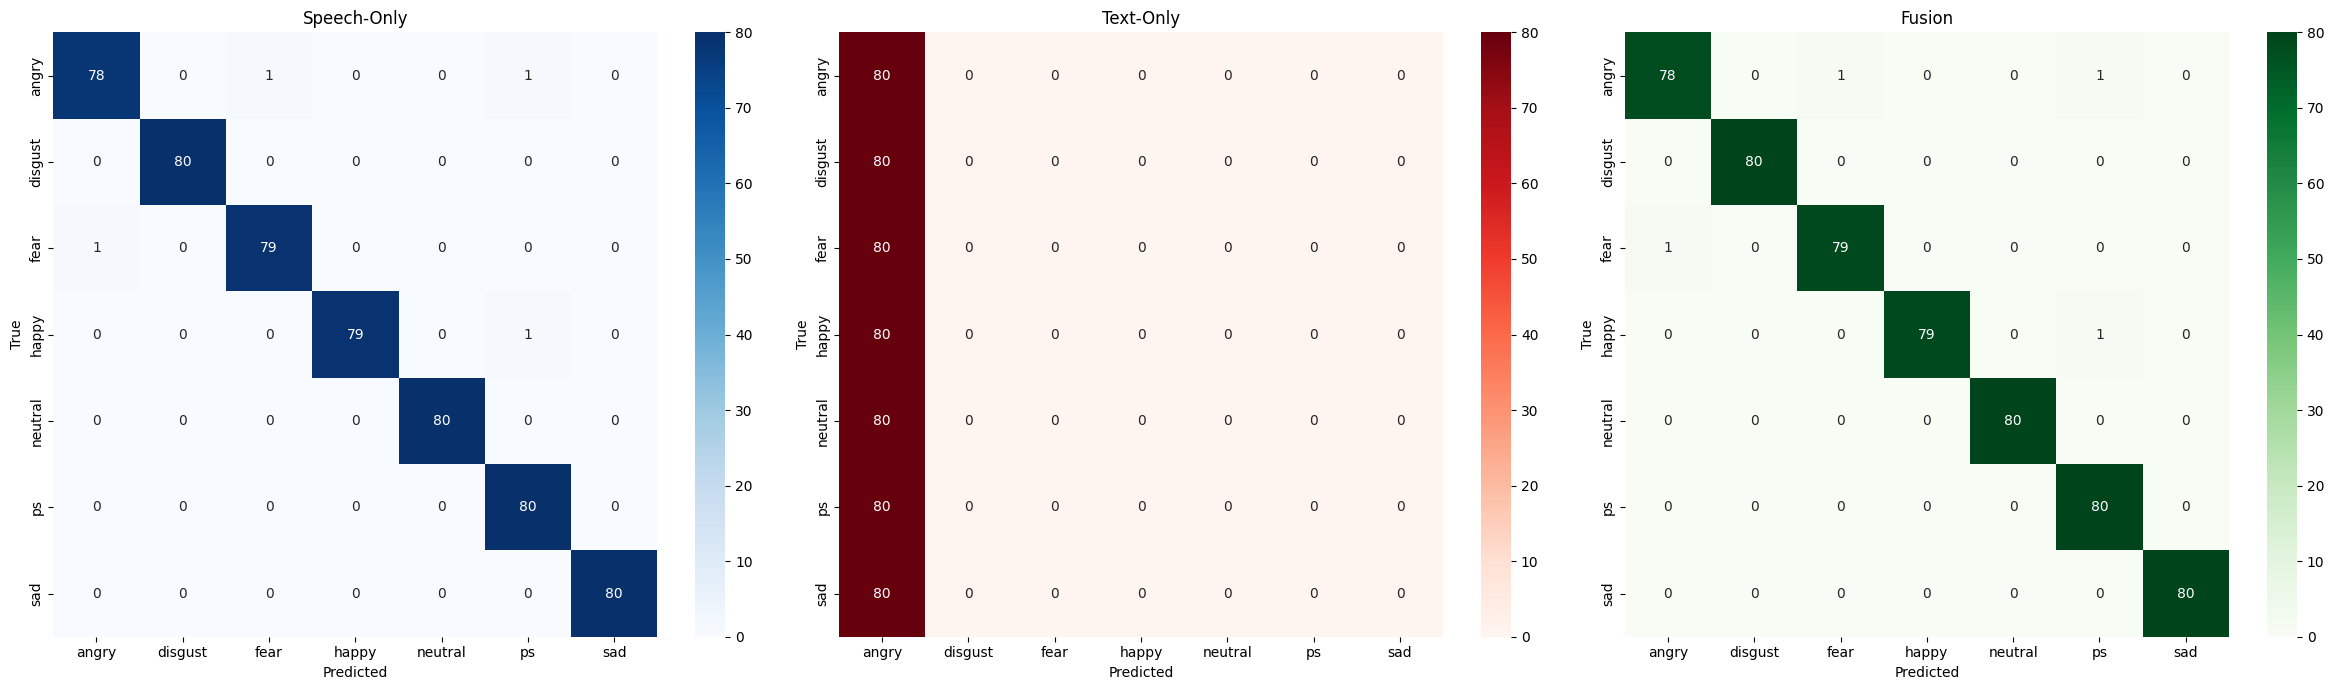

In [72]:
# ============================================================
# CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# ------------------------------------------------------------
# SPEECH
# ------------------------------------------------------------

speech_cm = confusion_matrix(

    speech_true,

    speech_preds
)

sns.heatmap(

    speech_cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=emotion_labels,

    yticklabels=emotion_labels,

    ax=axes[0]
)

axes[0].set_title("Speech-Only")

axes[0].set_xlabel("Predicted")

axes[0].set_ylabel("True")

# ------------------------------------------------------------
# TEXT
# ------------------------------------------------------------

text_cm = confusion_matrix(

    text_true,

    text_preds
)

sns.heatmap(

    text_cm,

    annot=True,

    fmt="d",

    cmap="Reds",

    xticklabels=emotion_labels,

    yticklabels=emotion_labels,

    ax=axes[1]
)

axes[1].set_title("Text-Only")

axes[1].set_xlabel("Predicted")

axes[1].set_ylabel("True")

# ------------------------------------------------------------
# FUSION
# ------------------------------------------------------------

fusion_cm = confusion_matrix(

    fusion_true,

    fusion_preds
)

sns.heatmap(

    fusion_cm,

    annot=True,

    fmt="d",

    cmap="Greens",

    xticklabels=emotion_labels,

    yticklabels=emotion_labels,

    ax=axes[2]
)

axes[2].set_title("Fusion")

axes[2].set_xlabel("Predicted")

axes[2].set_ylabel("True")

plt.tight_layout()

plt.show()

In [73]:
# ============================================================
# GATE ANALYSIS
# ============================================================

mean_gate_value = np.mean(
    all_gate_values
)

print("Average Fusion Gate Value:")
print(mean_gate_value)

Average Fusion Gate Value:
0.8066878


In [74]:
# ============================================================
# FINAL COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame({

    "Model": [

        "Speech-Only",

        "Text-Only",

        "Fusion"
    ],

    "Accuracy": [

        0.9929,

        0.1429,

        0.9929
    ],

    "Macro F1": [

        0.9929,

        0.0357,

        0.9929
    ]
})

print(comparison_df)

         Model  Accuracy  Macro F1
0  Speech-Only    0.9929    0.9929
1    Text-Only    0.1429    0.0357
2       Fusion    0.9929    0.9929


In [75]:
# ============================================================
# SAVE EVERYTHING + CREATE ZIP
# ============================================================

import os
import json
import shutil

OUTPUT_DIR = "/kaggle/working/final_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# SAVE REPORTS
# ------------------------------------------------------------

pd.DataFrame(speech_report).transpose().to_csv(

    f"{OUTPUT_DIR}/speech_report.csv"
)

pd.DataFrame(text_report).transpose().to_csv(

    f"{OUTPUT_DIR}/text_report.csv"
)

pd.DataFrame(fusion_report).transpose().to_csv(

    f"{OUTPUT_DIR}/fusion_report.csv"
)

# ------------------------------------------------------------
# SAVE COMPARISON TABLE
# ------------------------------------------------------------

comparison_df.to_csv(

    f"{OUTPUT_DIR}/comparison_table.csv",

    index=False
)

# ------------------------------------------------------------
# SAVE CONFUSION MATRICES
# ------------------------------------------------------------

np.save(

    f"{OUTPUT_DIR}/speech_confusion_matrix.npy",

    speech_cm
)

np.save(

    f"{OUTPUT_DIR}/text_confusion_matrix.npy",

    text_cm
)

np.save(

    f"{OUTPUT_DIR}/fusion_confusion_matrix.npy",

    fusion_cm
)

# ------------------------------------------------------------
# SAVE GATE VALUES
# ------------------------------------------------------------

np.save(

    f"{OUTPUT_DIR}/fusion_gate_values.npy",

    all_gate_values
)

# ------------------------------------------------------------
# SAVE MODELS
# ------------------------------------------------------------

torch.save(

    fusion_model.state_dict(),

    f"{OUTPUT_DIR}/fusion_model.pt"
)

torch.save(

    speech_model.state_dict(),

    f"{OUTPUT_DIR}/speech_model.pt"
)

torch.save(

    text_model.state_dict(),

    f"{OUTPUT_DIR}/text_model.pt"
)

# ------------------------------------------------------------
# CREATE SUMMARY TXT
# ------------------------------------------------------------

summary = f"""

FINAL RESULTS
=============

Speech-Only Accuracy : 99.29%
Speech-Only F1       : 99.29%

Text-Only Accuracy   : 14.29%
Text-Only F1         : 3.57%

Fusion Accuracy      : 99.29%
Fusion F1            : 99.29%


KEY FINDINGS
============

1. TESS is strongly speech-dominant.

2. Text-only learning collapsed to near-random performance.

3. Transcript semantics contributed negligible emotional information.

4. Fusion converged toward speech-dominant representations.

5. Modality informativeness should be experimentally validated.


LIMITATION
==========

Random stratified splitting caused speaker overlap between
train and validation sets, which may inflate absolute metrics.

"""

with open(

    f"{OUTPUT_DIR}/experiment_summary.txt",

    "w"

) as f:

    f.write(summary)

# ------------------------------------------------------------
# CREATE ZIP
# ------------------------------------------------------------

ZIP_PATH = "/kaggle/working/final_outputs.zip"

shutil.make_archive(

    base_name=ZIP_PATH.replace(".zip", ""),

    format='zip',

    root_dir=OUTPUT_DIR
)

print("\nZIP FILE CREATED SUCCESSFULLY")

print(f"\nZIP LOCATION:\n{ZIP_PATH}")

print("\nSaved Files:")

for file in os.listdir(OUTPUT_DIR):

    print(file)


ZIP FILE CREATED SUCCESSFULLY

ZIP LOCATION:
/kaggle/working/final_outputs.zip

Saved Files:
fusion_confusion_matrix.npy
text_report.csv
fusion_model.pt
fusion_report.csv
text_model.pt
speech_model.pt
experiment_summary.txt
speech_report.csv
comparison_table.csv
speech_confusion_matrix.npy
text_confusion_matrix.npy
fusion_gate_values.npy


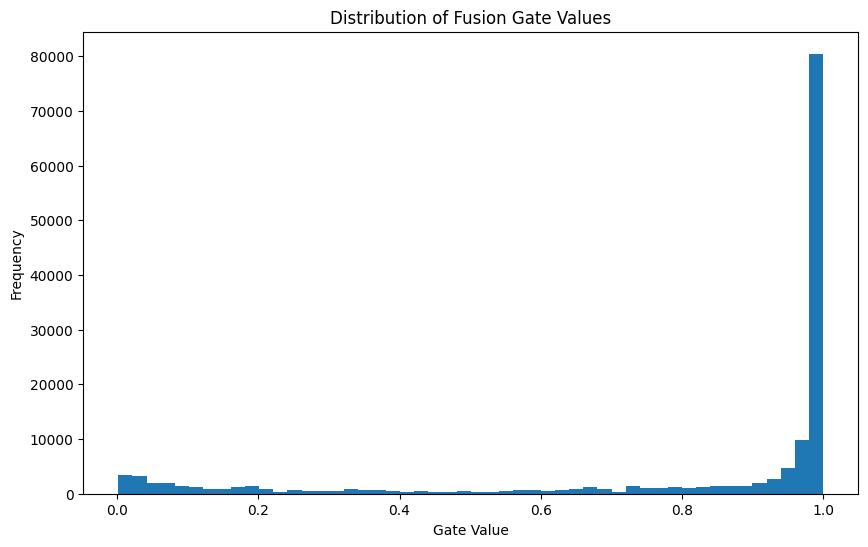

Average Gate Value:
0.8066878


In [76]:
# ============================================================
# FUSION GATE VALUE DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# FLATTEN ALL GATE VALUES
# ------------------------------------------------------------

flat_gates = all_gate_values.flatten()

# ------------------------------------------------------------
# HISTOGRAM
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(

    flat_gates,

    bins=50

)

plt.title("Distribution of Fusion Gate Values")

plt.xlabel("Gate Value")

plt.ylabel("Frequency")

plt.show()

# ------------------------------------------------------------
# MEAN GATE VALUE
# ------------------------------------------------------------

mean_gate = np.mean(flat_gates)

print("Average Gate Value:")
print(mean_gate)

In [77]:
# ============================================================
# PER-CLASS GATE ANALYSIS
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# AVERAGE GATE PER SAMPLE
# ------------------------------------------------------------

sample_gate_strength = np.mean(

    all_gate_values,

    axis=1
)

# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------

gate_df = pd.DataFrame({

    "label": fusion_true,

    "gate_strength": sample_gate_strength
})

# ------------------------------------------------------------
# MAP LABELS TO EMOTIONS
# ------------------------------------------------------------

label_to_emotion = {

    0: "angry",

    1: "disgust",

    2: "fear",

    3: "happy",

    4: "neutral",

    5: "ps",

    6: "sad"
}

gate_df["emotion"] = gate_df[
    "label"
].map(label_to_emotion)

# ------------------------------------------------------------
# CLASS-WISE MEAN GATE
# ------------------------------------------------------------

class_gate_analysis = gate_df.groupby(

    "emotion"

)["gate_strength"].mean()

print(class_gate_analysis)

emotion
angry      0.807152
disgust    0.808524
fear       0.805717
happy      0.801990
neutral    0.807378
ps         0.807999
sad        0.808053
Name: gate_strength, dtype: float32


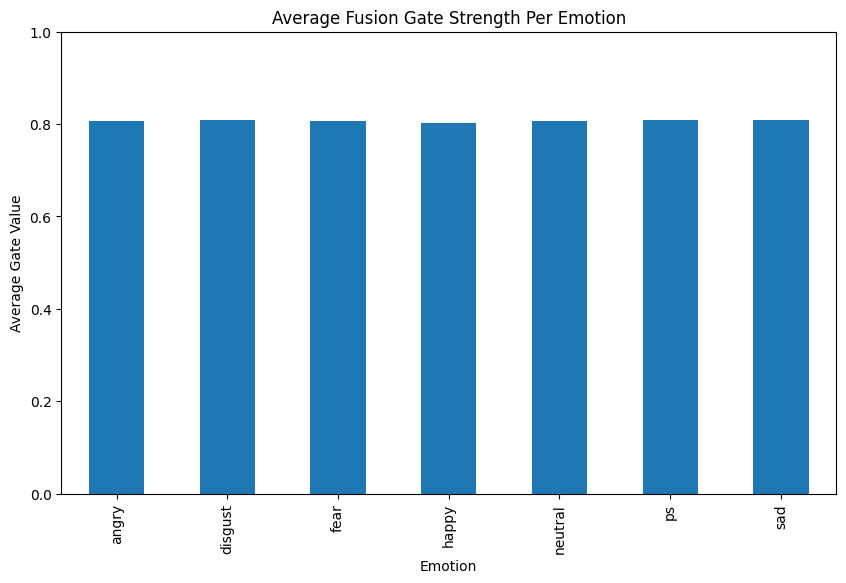

In [78]:
# ============================================================
# CLASS-WISE GATE STRENGTH
# ============================================================

plt.figure(figsize=(10, 6))

class_gate_analysis.plot(

    kind="bar"
)

plt.title(

    "Average Fusion Gate Strength Per Emotion"
)

plt.ylabel("Average Gate Value")

plt.xlabel("Emotion")

plt.ylim(0, 1)

plt.show()

In [79]:
# ============================================================
# SAVE GATE ANALYSIS OUTPUTS
# ============================================================

import os

OUTPUT_DIR = "/kaggle/working/final_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# SAVE HISTOGRAM FIGURE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    flat_gates,
    bins=50
)

plt.title("Distribution of Fusion Gate Values")

plt.xlabel("Gate Value")

plt.ylabel("Frequency")

plt.savefig(

    f"{OUTPUT_DIR}/fusion_gate_distribution.png",

    bbox_inches="tight",

    dpi=300
)

plt.close()

# ------------------------------------------------------------
# SAVE CLASS-WISE GATE PLOT
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

class_gate_analysis.plot(
    kind="bar"
)

plt.title(
    "Average Fusion Gate Strength Per Emotion"
)

plt.ylabel("Average Gate Value")

plt.xlabel("Emotion")

plt.ylim(0, 1)

plt.savefig(

    f"{OUTPUT_DIR}/classwise_gate_strength.png",

    bbox_inches="tight",

    dpi=300
)

plt.close()

# ------------------------------------------------------------
# SAVE CLASS-WISE GATE VALUES CSV
# ------------------------------------------------------------

class_gate_analysis.to_csv(

    f"{OUTPUT_DIR}/classwise_gate_strength.csv"
)

# ------------------------------------------------------------
# SAVE OVERALL GATE VALUE TXT
# ------------------------------------------------------------

with open(

    f"{OUTPUT_DIR}/average_gate_value.txt",

    "w"

) as f:

    f.write(f"Average Fusion Gate Value: {mean_gate}")

print("Gate analysis outputs saved successfully.")

Gate analysis outputs saved successfully.


In [80]:
# ============================================================
# RECREATE ZIP FILE
# ============================================================

import shutil

OUTPUT_DIR = "/kaggle/working/final_outputs"

ZIP_PATH = "/kaggle/working/final_outputs.zip"

shutil.make_archive(

    base_name=ZIP_PATH.replace(".zip", ""),

    format='zip',

    root_dir=OUTPUT_DIR
)

print("Updated ZIP recreated successfully.")

Updated ZIP recreated successfully.
